# HD Covariance Matrix Sanity Check

This notebook checks the Hellings–Downs (HD) covariance matrix produced by
`hd_full_matrix_snr.py` against the geometric quantities it's built from
(star positions, pairwise separations, and $\gamma_{ab}$ values), and
against the full $C_{ab,cd}$ derivation for all three structural cases:
no shared star, one shared star, and the diagonal (same pair).

Two star-field sizes are used for the geometry/plotting walkthrough
(**N = 3** and **N = 10**).


In [75]:
import numpy as np

# Functions/constants from your existing scripts
from main import (
    build_star_positions,
    pairwise_theta,
    compute_ell_limits,
    gamma_parallel,
    STAR_COORDS_DEG,
    FIELD_SIZE_DEG,
    RANDOM_SEED,
    sigma_bar_sq,
)

from hd_full_matrix_snr import build_HD_matrices, F_PHYS

# main.py calls matplotlib.use('Agg') on import (needed for Slurm jobs),
# which would otherwise stop figures from showing up inline here.
# Re-import after the above and force the inline backend for this notebook.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
%matplotlib inline

print(f"F_PHYS = 192*pi^3 = {F_PHYS:.6f}")
print(f"FIELD_SIZE_DEG (default from main.py) = {FIELD_SIZE_DEG}")
print(f"sigma_bar_sq (= P_n, noise floor) = {sigma_bar_sq:.6e}")


F_PHYS = 192*pi^3 = 5953.205123
FIELD_SIZE_DEG (default from main.py) = 10
sigma_bar_sq (= P_n, noise floor) = 8.461595e-14


## 0. Validate the spherical geometry

Before anything else, chcking that the spherical
`build_star_positions` / `pairwise_theta` behave correctly at known
angular separations.


In [76]:
# --- Known angular separations ---
known_pts = np.array([
    [0, 0],     # reference
    [0, 0],     # same point -> separation 0
    [180, 0],   # antipodal on the equator -> separation pi
    [90, 0],    # 90 deg away on the equator
    [0, 90],    # the north pole
])
theta_known = pairwise_theta(known_pts)
print("Known-separation checks:")
print(f"  same point:        {theta_known[0,1]:.6f} rad  (expect 0)")
print(f"  antipodal (180deg): {theta_known[0,2]:.6f} rad  (expect {np.pi:.6f})")
print(f"  90 deg on equator: {theta_known[0,3]:.6f} rad  (expect {np.pi/2:.6f})")
print(f"  to north pole:     {theta_known[0,4]:.6f} rad  (expect {np.pi/2:.6f})")


Known-separation checks:
  same point:        0.000000 rad  (expect 0)
  antipodal (180deg): 3.141593 rad  (expect 3.141593)
  90 deg on equator: 1.570796 rad  (expect 1.570796)
  to north pole:     1.570796 rad  (expect 1.570796)


In [77]:
print("Field-size containment check (stars should stay within field_size_deg/2 of center):\n")
for fov in [10, 90, 180, 360]:
    test_stars = build_star_positions(STAR_COORDS_DEG, n_stars=2000, field_size_deg=fov,
                                       seed=RANDOM_SEED, center_ra_deg=0, center_dec_deg=0)
    center = np.array([[0.0, 0.0]])
    sep_from_center = pairwise_theta(np.vstack([center, test_stars]))[0, 1:]
    max_sep_deg = np.degrees(np.max(sep_from_center))
    print(f"  field_size_deg={fov:>4}: max separation from center = {max_sep_deg:6.2f} deg "
          f"(must be <= {fov/2:.1f})")


Field-size containment check (stars should stay within field_size_deg/2 of center):

  field_size_deg=  10: max separation from center =   5.00 deg (must be <= 5.0)
  field_size_deg=  90: max separation from center =  45.00 deg (must be <= 45.0)
  field_size_deg= 180: max separation from center =  90.00 deg (must be <= 90.0)
  field_size_deg= 360: max separation from center = 179.22 deg (must be <= 180.0)


## 1. Generate 3 stars and plot their positions

Using `build_star_positions` from `main.py`. Passing `n_stars=3` explicitly
(overriding the default `N_STARS=100` from `main.py`) and reusing the same
`FIELD_SIZE_DEG` and `RANDOM_SEED` so the geometry is reproducible.


Star positions (degrees):
[[ 0.76092636  0.05600109]
 [ 3.571759    1.65452452]
 [ 0.93589715 -1.02073957]]


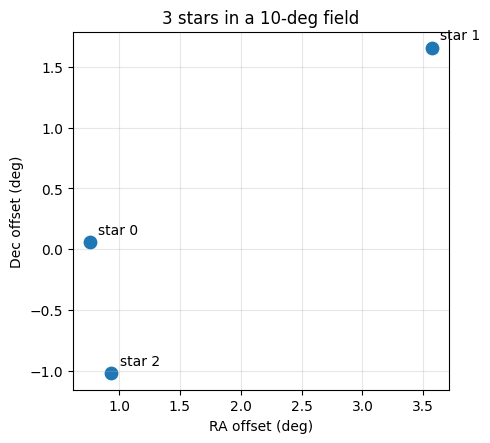

In [78]:
N_STARS_3 = 3

stars_3 = build_star_positions(
    STAR_COORDS_DEG,
    n_stars=N_STARS_3,
    field_size_deg=FIELD_SIZE_DEG,
    seed=RANDOM_SEED,
)

print("Star positions (degrees):")
print(stars_3)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(stars_3[:, 0], stars_3[:, 1], s=80, color="C0")
for i, (x, y) in enumerate(stars_3):
    ax.annotate(f"star {i}", (x, y), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("RA offset (deg)")
ax.set_ylabel("Dec offset (deg)")
ax.set_title(f"{N_STARS_3} stars in a {FIELD_SIZE_DEG}-deg field")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Histogram of pairwise separations

With only 3 stars there are just 3 pairs, so this is mostly a
sanity check that the values are non-negative, finite, and reasonable for a
field of this size. Set to NaN on the diagonal so the histogram isn't skewed by
the zero values from a star's separation from itself.



Pairwise separation matrix (radians):
[[       nan 0.05643053 0.01903915]
 [0.05643053        nan 0.0655448 ]
 [0.01903915 0.0655448         nan]]

Pairwise separations (degrees): [3.23323118 1.09086303 3.75544014]


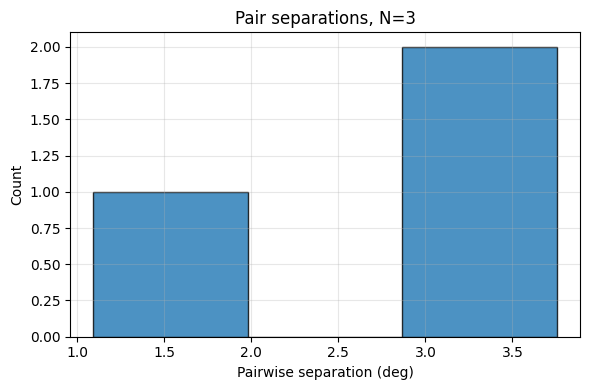

In [79]:
theta_3 = pairwise_theta(stars_3)
print("Pairwise separation matrix (radians):")
print(theta_3)

# Upper-triangle pairs only (avoid double counting / NaN diagonal)
rows3, cols3 = np.triu_indices(N_STARS_3, k=1)
theta_pairs_3 = theta_3[rows3, cols3]
theta_pairs_3_deg = np.degrees(theta_pairs_3)

print("\nPairwise separations (degrees):", theta_pairs_3_deg)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(theta_pairs_3_deg, bins=min(10, len(theta_pairs_3_deg)), color="C0", edgecolor="k", alpha=0.8)
ax.set_xlabel("Pairwise separation (deg)")
ax.set_ylabel("Count")
ax.set_title(f"Pair separations, N={N_STARS_3}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. ell_min / ell_max and histogram of gamma values

`compute_ell_limits` sets `ell_min = 2` and `ell_max` from the minimum
pairwise separation (`2*pi / theta_min`). We then evaluate
`gamma_parallel` on the same separations to get the overlap-function
values for each pair.


ell_min = 2, ell_max = 330

Full gamma matrix (NaN on diagonal):
[[       nan 0.00659469 0.00662725]
 [0.00659469        nan 0.00658193]
 [0.00662725 0.00658193        nan]]

gamma values for each pair: [0.00659469 0.00662725 0.00658193]


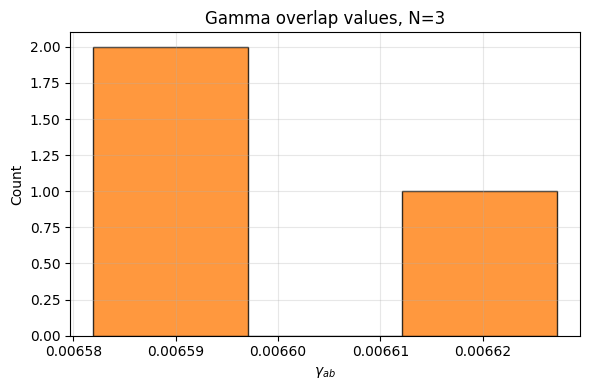

In [80]:
ell_min_3, ell_max_3 = compute_ell_limits(theta_3, FIELD_SIZE_DEG)
print(f"ell_min = {ell_min_3}, ell_max = {ell_max_3}")

gamma_3 = gamma_parallel(theta_3, ell_min_3, ell_max_3)
print("\nFull gamma matrix (NaN on diagonal):")
print(gamma_3)

gamma_pairs_3 = gamma_3[rows3, cols3]
print("\ngamma values for each pair:", gamma_pairs_3)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gamma_pairs_3, bins=min(10, len(gamma_pairs_3)), color="C1", edgecolor="k", alpha=0.8)
ax.set_xlabel(r"$\gamma_{ab}$")
ax.set_ylabel("Count")
ax.set_title(f"Gamma overlap values, N={N_STARS_3}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Build the HD covariance matrix

`build_HD_matrices` returns the pair
index list and the three pieces `A`, `B`, `D` such that the full
covariance operator is

$$M(r) = A + \frac{B}{r} + \frac{D}{r^2}$$

where $r = P_{gw}/P_n$ is the GW-to-noise power ratio (the x-axis variable
in the SNR curves).


In [81]:
pairs_3, A_3, B_3, D_3 = build_HD_matrices(gamma_3)
print("Pair list (star index a, star index b):")
print(pairs_3)

r_test = 1e-3   # arbitrary but representative GW-to-noise ratio for this check
M_3 = A_3 + B_3 / r_test + D_3 / r_test**2

print(f"\nM(r={r_test:.1e})")
print(M_3)
print(f"\nDiagonal entries (one per pair)")
for i, (a, b) in enumerate(pairs_3):
    print(f"  pair ({a},{b}): M[{i},{i}] = {M_3[i,i]:.6f}   (gamma_ab = {gamma_3[a,b]:.6f})")


Pair list (star index a, star index b):
[[0 1]
 [0 2]
 [1 2]]

M(r=1.0e-03)
[[651.09617709  26.32261899  26.67254901]
 [ 26.32261899 644.72360684  26.42089375]
 [ 26.67254901  26.42089375 653.61914056]]

Diagonal entries (one per pair)
  pair (0,1): M[0,0] = 651.096177   (gamma_ab = 0.006595)
  pair (0,2): M[1,1] = 644.723607   (gamma_ab = 0.006627)
  pair (1,2): M[2,2] = 653.619141   (gamma_ab = 0.006582)


## 5. Plot the covariance matrix with `imshow`

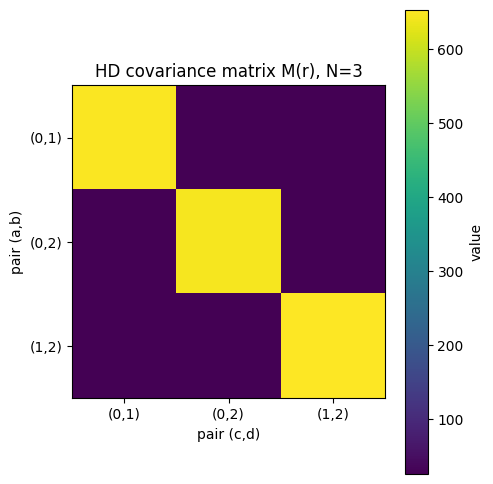

In [82]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(M_3, cmap="viridis")
ax.set_xticks(range(len(pairs_3)))
ax.set_yticks(range(len(pairs_3)))
pair_labels = [f"({a},{b})" for a, b in pairs_3]
ax.set_xticklabels(pair_labels)
ax.set_yticklabels(pair_labels)
ax.set_xlabel("pair (c,d)")
ax.set_ylabel("pair (a,b)")
ax.set_title(f"HD covariance matrix M(r), N={N_STARS_3}")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()


## 6. Check matrix entries against the calculated $C_{ab,cd}$

The pair-space covariance has three structurally different cases:

- **Case 1** ($a,b,c,d$ all distinct, no shared star): pure GW-signal
  term, no noise contribution.
- **Case 2** (one shared star, e.g. $a=c$): mixes one auto-covariance
  (noise) with GW signal.
- **Case 3** (same pair, i.e. the diagonal $a=c,\,b=d$): both stars'
  noise enters.

With the full noise convention $P_a(f) = P_{na}(f) + P_{gw}(f)$ for every
star (each star's total power is noise plus the GW signal it's
carrying), and writing $\tilde\Gamma_{ab} = F\cdot\gamma_{ab}$ with
$F=192\pi^3$, the three cases work out to:

$$C_{ab,cd} = \frac{\tilde\Gamma_{ac}\tilde\Gamma_{bd} + \tilde\Gamma_{ad}\tilde\Gamma_{bc}}{\tilde\Gamma_{ab}\tilde\Gamma_{cd}} \qquad \text{(Case 1, no $r$-dependence)}$$

$$C_{ab,ad} = 1 + \frac{P_a}{P_{gw}}\cdot\frac{\tilde\Gamma_{bd}}{\tilde\Gamma_{ab}\tilde\Gamma_{ad}} = 1 + \left(\frac{1}{r}+1\right)\frac{\tilde\Gamma_{bd}}{\tilde\Gamma_{ab}\tilde\Gamma_{ad}} \qquad \text{(Case 2, shared star $a$)}$$

$$C_{ab,ab} = 1 + \frac{P_aP_b}{P_{gw}^2}\cdot\frac{1}{\tilde\Gamma_{ab}^2} = 1 + \left(\frac{1}{r^2}+\frac{2}{r}+1\right)\frac{1}{\tilde\Gamma_{ab}^2} \qquad \text{(Case 3, diagonal)}$$

(prefactors omitted here as they are shared across all 3 cases and I am only checking the shape right now)


In [83]:
def Fg(gamma_mat, i, j):
    """tilde-Gamma_ij = F_PHYS * gamma_ij"""
    return F_PHYS * gamma_mat[i, j]

# ---- Need >=4 stars to have a Case-1 pair (two pairs sharing zero stars) ----
N_STARS_4 = 4
stars_4 = build_star_positions(
    STAR_COORDS_DEG, n_stars=N_STARS_4, field_size_deg=FIELD_SIZE_DEG, seed=RANDOM_SEED
)
theta_4 = pairwise_theta(stars_4)
ell_min_4, ell_max_4 = compute_ell_limits(theta_4, FIELD_SIZE_DEG)
gamma_4 = gamma_parallel(theta_4, ell_min_4, ell_max_4)
pairs_4, A_4, B_4, D_4 = build_HD_matrices(gamma_4)   
M_4 = A_4 + B_4 / r_test + D_4 / r_test**2

pair_to_idx_4 = {tuple(p): i for i, p in enumerate(pairs_4)}

Pgw_test = r_test * sigma_bar_sq
Pa_full  = sigma_bar_sq + Pgw_test    

# --- Case 1: pairs (0,1) and (2,3) share no star ---
i_ab, i_cd = pair_to_idx_4[(0, 1)], pair_to_idx_4[(2, 3)]
a, b = pairs_4[i_ab]
c, d = pairs_4[i_cd]
Fac, Fbd, Fad, Fbc = Fg(gamma_4,a,c), Fg(gamma_4,b,d), Fg(gamma_4,a,d), Fg(gamma_4,b,c)
Fab, Fcd = Fg(gamma_4,a,b), Fg(gamma_4,c,d)
case1_expected = (Fac*Fbd + Fad*Fbc) / (Fab*Fcd)
case1_code = M_4[i_ab, i_cd]
print("=== Case 1 (no shared star): pairs (0,1) & (2,3) ===")
print(f"  M[{i_ab},{i_cd}] from matrix code   = {case1_code:.6f}")
print(f"  calculated full          = {case1_expected:.6f}")
print(f"  Match: {np.isclose(case1_code, case1_expected)}")

# --- Case 2: pairs (0,1) and (0,2) share star 0 ---
i_ab2, i_ad2 = pair_to_idx_4[(0, 1)], pair_to_idx_4[(0, 2)]
a2, b2 = pairs_4[i_ab2]
_,  d2 = pairs_4[i_ad2]
Fbd2 = Fg(gamma_4, b2, d2); Fab2 = Fg(gamma_4, a2, b2); Fad2 = Fg(gamma_4, a2, d2)
case2_full = 1 + (Pa_full/Pgw_test) * Fbd2/(Fab2*Fad2)
case2_code = M_4[i_ab2, i_ad2]
print()
print("=== Case 2 (one shared star): pairs (0,1) & (0,2), shared star = 0 ===")
print(f"  M[{i_ab2},{i_ad2}] from matrix code  = {case2_code:.6f}")
print(f"  calculated full           = {case2_full:.6f}")
print(f"  Match: {np.isclose(case2_code, case2_full)}")

# --- Case 3 (diagonal): pair (0,1) ---
i_diag = i_ab2
a3, b3 = pairs_4[i_diag]
Fab3 = Fg(gamma_4, a3, b3)
case3_full = 1 + (Pa_full*Pa_full)/(Pgw_test**2) * (1.0/Fab3**2)
case3_code = M_4[i_diag, i_diag]
print()
print("=== Case 3 (diagonal): pair (0,1) ===")
print(f"  M[{i_diag},{i_diag}] from matrix code = {case3_code:.6f}")
print(f"  calculated full         = {case3_full:.6f}")
print(f"  Match: {np.isclose(case3_code, case3_full)}")


=== Case 1 (no shared star): pairs (0,1) & (2,3) ===
  M[0,5] from matrix code   = 2.001005
  calculated full          = 2.001005
  Match: True

=== Case 2 (one shared star): pairs (0,1) & (0,2), shared star = 0 ===
  M[0,1] from matrix code  = 26.426388
  calculated full           = 26.426388
  Match: True

=== Case 3 (diagonal): pair (0,1) ===
  M[0,0] from matrix code = 653.722658
  calculated full         = 653.722658
  Match: True


## 8. Exhaustive check across every pair combination

Every Case-1 & Case-2 (all four shared-index sub-variants) and diagonal entries on a 6-star
(15-pair) field checked against the full formula directly.


In [84]:
N_STARS_6 = 6
stars_6 = build_star_positions(
    STAR_COORDS_DEG, n_stars=N_STARS_6, field_size_deg=FIELD_SIZE_DEG, seed=RANDOM_SEED
)
theta_6 = pairwise_theta(stars_6)
ell_min_6, ell_max_6 = compute_ell_limits(theta_6, FIELD_SIZE_DEG)
gamma_6 = gamma_parallel(theta_6, ell_min_6, ell_max_6)

pairs_6, A_6, B_6, D_6 = build_HD_matrices(gamma_6) 
n_pairs_6 = len(pairs_6)
M_6 = A_6 + B_6 / r_test + D_6 / r_test**2

a_idx6 = pairs_6[:, 0]; b_idx6 = pairs_6[:, 1]
a_i6 = a_idx6[:, None]; b_i6 = b_idx6[:, None]
c_j6 = a_idx6[None, :]; d_j6 = b_idx6[None, :]
ac6 = a_i6 == c_j6; bc6 = b_i6 == c_j6; ad6 = a_i6 == d_j6; bd6 = b_i6 == d_j6
case1_6 = ~ac6 & ~bc6 & ~ad6 & ~bd6
case2_6 = (ac6 | bc6 | ad6 | bd6) & ~(ac6 & bd6)

Fg_pair_6 = F_PHYS * gamma_6[pairs_6[:, 0], pairs_6[:, 1]]
Fg_mat_6  = F_PHYS * gamma_6
Pgw_6 = r_test * sigma_bar_sq
Pa_full_6 = sigma_bar_sq + Pgw_6

rows1, cols1 = np.where(case1_6)
case1_ok = True
for i, j in zip(rows1, cols1):
    a, b = pairs_6[i]; c, d = pairs_6[j]
    expected = (Fg_mat_6[a,c]*Fg_mat_6[b,d] + Fg_mat_6[a,d]*Fg_mat_6[b,c]) / (Fg_pair_6[i]*Fg_pair_6[j])
    if not np.isclose(M_6[i, j], expected):
        case1_ok = False
print(f"Case 1: all {len(rows1)} entries match: {case1_ok}")

rows2, cols2 = np.where(case2_6)
case2_ok = True
for i, j in zip(rows2, cols2):
    pi, pj = tuple(pairs_6[i]), tuple(pairs_6[j])
    s = (set(pi) & set(pj)).pop()
    p = [x for x in pi if x != s][0]
    q = [x for x in pj if x != s][0]
    Fpq = Fg_mat_6[p, q]
    expected = 1 + (Pa_full_6/Pgw_6) * Fpq / (Fg_pair_6[i]*Fg_pair_6[j])
    if not np.isclose(M_6[i, j], expected):
        case2_ok = False
print(f"Case 2: all {len(rows2)} entries match: {case2_ok}")

case3_ok = True
for i in range(n_pairs_6):
    Fab_i = Fg_pair_6[i]
    expected = 1 + (Pa_full_6*Pa_full_6)/(Pgw_6**2) * (1.0/Fab_i**2)
    if not np.isclose(M_6[i, i], expected):
        case3_ok = False
print(f"Case 3 (diagonal): all {n_pairs_6} entries match: {case3_ok}")


Case 1: all 90 entries match: True
Case 2: all 120 entries match: True
Case 3 (diagonal): all 15 entries match: True


## 9. Repeat the geometry walkthrough for N = 10 stars

Same steps as Sections 1-5, larger field of stars, using `build_HD_matrices` throughout.


N = 10 stars -> 45 pairs
ell_min = 2, ell_max = 2005


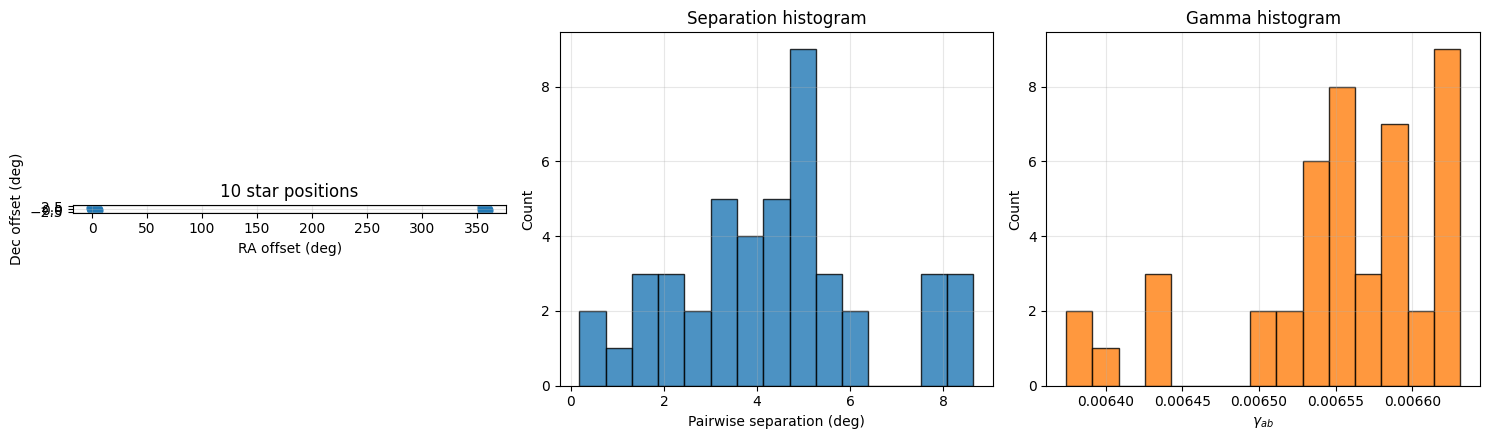

In [85]:
N_STARS_10 = 10

stars_10 = build_star_positions(
    STAR_COORDS_DEG,
    n_stars=N_STARS_10,
    field_size_deg=FIELD_SIZE_DEG,
    seed=RANDOM_SEED,
)

theta_10 = pairwise_theta(stars_10)
ell_min_10, ell_max_10 = compute_ell_limits(theta_10, FIELD_SIZE_DEG)
gamma_10 = gamma_parallel(theta_10, ell_min_10, ell_max_10)

rows10, cols10 = np.triu_indices(N_STARS_10, k=1)
theta_pairs_10_deg = np.degrees(theta_10[rows10, cols10])
gamma_pairs_10 = gamma_10[rows10, cols10]

print(f"N = {N_STARS_10} stars -> {len(theta_pairs_10_deg)} pairs")
print(f"ell_min = {ell_min_10}, ell_max = {ell_max_10}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(stars_10[:, 0], stars_10[:, 1], s=60, color="C0")
axes[0].set_xlabel("RA offset (deg)")
axes[0].set_ylabel("Dec offset (deg)")
axes[0].set_title(f"{N_STARS_10} star positions")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.3)

axes[1].hist(theta_pairs_10_deg, bins=15, color="C0", edgecolor="k", alpha=0.8)
axes[1].set_xlabel("Pairwise separation (deg)")
axes[1].set_ylabel("Count")
axes[1].set_title("Separation histogram")
axes[1].grid(alpha=0.3)

axes[2].hist(gamma_pairs_10, bins=15, color="C1", edgecolor="k", alpha=0.8)
axes[2].set_xlabel(r"$\gamma_{ab}$")
axes[2].set_ylabel("Count")
axes[2].set_title("Gamma histogram")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Build N=10 stars covariance matrix

[[652.9538  26.3538  26.3999 ...   1.9732   2.0027   1.9916]
 [ 26.3538 646.9051  26.6361 ...   1.9904   2.0245   2.0073]
 [ 26.3999  26.6361 661.0834 ...   1.9856   2.0344   2.024 ]
 ...
 [  1.9732   1.9904   1.9856 ... 651.1309  26.9703  26.0336]
 [  2.0027   2.0245   2.0344 ...  26.9703 683.6531  27.2859]
 [  1.9916   2.0073   2.024  ...  26.0336  27.2859 659.0306]]


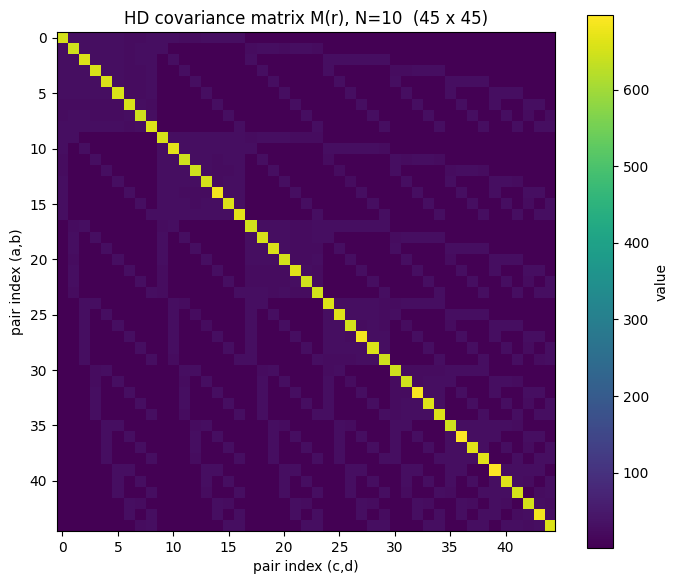

In [93]:
pairs_10, A_10, B_10, D_10 = build_HD_matrices(gamma_10) 
M_10 = A_10 + B_10 / r_test + D_10 / r_test**2
np.set_printoptions(precision=4, suppress=True, linewidth=200)
print(M_10)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(M_10, cmap="viridis")
ax.set_xlabel("pair index (c,d)")
ax.set_ylabel("pair index (a,b)")
ax.set_title(f"HD covariance matrix M(r), N={N_STARS_10}  ({len(pairs_10)} x {len(pairs_10)})")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()


## Diagonal Check for N=10

In [ ]:
pair_idx_10 = 5
a10, b10 = pairs_10[pair_idx_10]

M_diag_entry_10 = M_10[pair_idx_10, pair_idx_10]
Fab_10 = F_PHYS * gamma_10[a10, b10]
Pgw_10 = r_test * sigma_bar_sq
Pab_full_10 = sigma_bar_sq + Pgw_10
C_ab_ab_calculated_10 = 1.0 + (Pab_full_10 * Pab_full_10) / (Pgw_10**2) * (1.0 / Fab_10**2)

print(f"Checking diagonal entry for pair (a={a10}, b={b10}) at r={r_test:.1e}, N=10")
print(f"  M[{pair_idx_10},{pair_idx_10}] from matrix (current code) = {M_diag_entry_10:.6f}")
print(f"  C_ab,ab calculated (P_a=P_b=P_na+P_gw)           = {C_ab_ab_calculated_10:.6f}")
print(f"  Match: {np.isclose(M_diag_entry_10, C_ab_ab_calculated_10)}")


Checking diagonal entry for pair (a=0, b=6) at r=1.0e-03, N=10
  M[5,5] from matrix (current code) = 658.671022
  C_ab,ab calculated (P_a=P_b=P_na+P_gw)           = 658.671022
  Match: True
